# ModelizaciónRF · vf (features acústicas propias + normalización por género)

El objetivo de este código es utilizar el dataframe de la muestra con features acústicas (calculado en apartados previos) para creación de un modelo tipo RandomForest. Se realiza también el análisis de interpretabilidad via SHAP values (via `TreeExplainer`)

## 0. Setup
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import getpass
from pathlib import Path

from scipy.stats import randint

from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              roc_auc_score, f1_score, accuracy_score,
                              precision_recall_fscore_support,
                              ConfusionMatrixDisplay)
import shap

import warnings
warnings.filterwarnings('ignore')

c:\Users\tblxa\Desktop\Master\UNIR_IA_TFE\unir_tfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# TODO
# Path con dataframe de features vf (features acústicas propias, sin velocidad de habla)
# path_df_features = Path(getpass.getpass("Ruta con df input: "))
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
path_df_features = PROJECT_DIR + '/output/df_acoustic_features_vf.csv'

In [4]:
##################################################
####           Constantes del modelo          ####
##################################################

PHQ_THRESHOLD = 10      # umbral clínico PHQ-8: >= 10 → depresión moderada-severa
RANDOM_STATE  = 42
N_ITER_SEARCH = 100     # iteraciones RandomizedSearchCV
N_CV_FOLDS    = 5       # folds en validación cruzada estratificada
K_FEATURES    = 20      # nº de features seleccionadas (SelectKBest) — mismo valor que el MLP

# Columnas excluidas del modelo:
# - participant_id, path_*: identificadores / rutas, no predictores
# - phq8_binary: derivado directamente del target → data leakage
# - split: columna de partición, no feature
# - durAudio, durSession: metadatos de sesión
COLS_EXCLUDE = ['participant_id', 'phq8_binary', 'path_audio',
                'path_transcript', 'split', 'durAudio', 'durSession']
TARGET = 'phq8_score'

# Prefijos de las features acústicas (las que se normalizan por género).
# gender se usa SOLO para normalizar (se elimina como feature); el resto de
# variables prosódicas/temporales no se normalizan.
ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')

## 1. Preparación del dataset
---

In [5]:
df = pd.read_csv(path_df_features)

COLS_FEATURES = [c for c in df.columns if c not in COLS_EXCLUDE + [TARGET]]
ACOUSTIC_COLS = [c for c in COLS_FEATURES if c.startswith(ACOUSTIC_PREFIXES)]
OTHER_COLS    = [c for c in COLS_FEATURES if c not in ACOUSTIC_COLS]

print(f"Sesiones: {len(df)}  |  Features: {len(COLS_FEATURES)}")
print(f"  • acústicas (norm. por género): {len(ACOUSTIC_COLS)}")
print(f"  • resto (turnos/pausas + gender): {len(OTHER_COLS)}")
print(f"\n── Distribución PHQ-8 (target) ──────────────────")
print(df[TARGET].describe().round(2).to_string())
print(f"\nDeprimidos (PHQ-8 ≥ {PHQ_THRESHOLD}): "
      f"{(df[TARGET] >= PHQ_THRESHOLD).sum()} / {len(df)}  "
      f"({100*(df[TARGET] >= PHQ_THRESHOLD).mean():.1f}%)")

Sesiones: 186  |  Features: 60
  • acústicas (norm. por género): 45
  • resto (turnos/pausas + gender): 15

── Distribución PHQ-8 (target) ──────────────────
count    186.00
mean       6.80
std        5.95
min        0.00
25%        2.00
50%        5.50
75%       10.00
max       23.00

Deprimidos (PHQ-8 ≥ 10): 57 / 186  (30.6%)


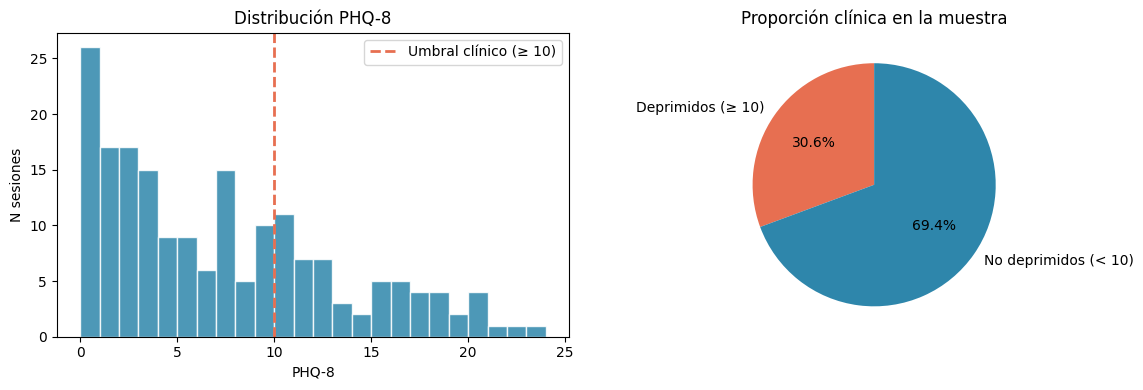

In [6]:
# Distribución del target — el desbalanceo condiciona la estrategia de CV
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=range(0, 25), color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0].axvline(PHQ_THRESHOLD, color='#E76F51', lw=2, ls='--',
                label=f'Umbral clínico (≥ {PHQ_THRESHOLD})')
axes[0].set_xlabel('PHQ-8')
axes[0].set_ylabel('N sesiones')
axes[0].set_title('Distribución PHQ-8')
axes[0].legend()

axes[1].pie(
    [(df[TARGET] >= PHQ_THRESHOLD).sum(), (df[TARGET] < PHQ_THRESHOLD).sum()],
    labels=[f'Deprimidos (≥ {PHQ_THRESHOLD})', f'No deprimidos (< {PHQ_THRESHOLD})'],
    colors=['#E76F51', '#2E86AB'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción clínica en la muestra')

plt.tight_layout()
plt.show()

In [7]:
# Splits: se respeta la partición predefinida del corpus DAIC-WOZ
# train+dev → ajuste del modelo y selección de hiperparámetros vía CV
# test       → evaluación final (se toca una única vez)
df_traindev = df[df['split'].isin(['train', 'dev'])].reset_index(drop=True)
df_test      = df[df['split'] == 'test'].reset_index(drop=True)

X_traindev = df_traindev[COLS_FEATURES]
y_traindev = df_traindev[TARGET]
X_test     = df_test[COLS_FEATURES]
y_test     = df_test[TARGET]

# CV estratificada sobre phq8_binary:
# garantiza que la proporción deprimidos/no deprimidos sea representativa en cada fold,
# evitando que algún fold quede sin (o con todos) los casos positivos
cv_strat  = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv_strat.split(X_traindev, (y_traindev >= PHQ_THRESHOLD).astype(int)))

n_dep_td = (y_traindev >= PHQ_THRESHOLD).sum()
n_dep_t  = (y_test     >= PHQ_THRESHOLD).sum()
print(f"Train+Dev : {len(df_traindev):>3} sesiones  "
      f"({n_dep_td} deprimidos, {len(df_traindev)-n_dep_td} no deprimidos)")
print(f"Test      : {len(df_test):>3} sesiones  "
      f"({n_dep_t} deprimidos, {len(df_test)-n_dep_t} no deprimidos)")
print(f"\nCV: {N_CV_FOLDS}-fold estratificada (stratify=phq8_binary)")

Train+Dev : 140 sesiones  (43 deprimidos, 97 no deprimidos)
Test      :  46 sesiones  (14 deprimidos, 32 no deprimidos)

CV: 5-fold estratificada (stratify=phq8_binary)


### Normalización acústica por género

Las features acústicas (F0, espectrales, calidad vocal) dependen fuertemente del sexo: un F0 de 180 Hz es bajo para una mujer pero alto para un hombre. Si se entrega el valor crudo, el árbol tiene que **separar primero por género** y luego aprender umbrales distintos en cada rama, lo que con solo ~47 deprimidos en train+dev divide aún más una señal ya escasa.

La solución es **z-scorear cada feature acústica dentro de su género**: `(x − μ_género) / σ_género`. Así un mismo valor normalizado significa "lo mismo" en ambos sexos (desviación respecto a la norma de su grupo), y el árbol puede capturar la señal de depresión con un único corte en lugar de dos ramas.

**Punto crítico (sin data leakage):** las estadísticas μ y σ se aprenden **solo con los datos de entrenamiento** de cada fold. Se implementa como un `TransformerMixin` dentro de un `Pipeline`, de modo que en `RandomizedSearchCV` y en la CV la normalización se reajusta en cada fold con su train y se aplica al validation, nunca al revés. La transformación es independiente del target (`phq8`), por lo que el único riesgo de fuga sería estadístico (usar μ/σ del conjunto completo), que el pipeline elimina.

> Nota: aunque Random Forest es invariante a escalados globales, la normalización **por género** aplica transformaciones distintas a cada subgrupo, alterando el orden relativo entre hombres y mujeres. Por eso sí afecta (favorablemente) a los cortes del árbol.

In [8]:
class GenderZScoreScaler(BaseEstimator, TransformerMixin):
    """
    Z-score de las columnas `cols` DENTRO de cada grupo de `gender_col`.

    Las medias y desviaciones se aprenden en fit (train) y se aplican en
    transform (val/test), por lo que dentro de un Pipeline + CV no hay fuga de
    información. Espera un DataFrame que contenga `gender_col` y `cols`.
    """
    def __init__(self, cols, gender_col='gender'):
        self.cols = cols
        self.gender_col = gender_col

    def fit(self, X, y=None):
        self.stats_ = {}
        for g, sub in X.groupby(self.gender_col):
            mu = sub[self.cols].mean()
            sd = sub[self.cols].std(ddof=0).replace(0, 1.0)   # evita división por 0
            self.stats_[g] = (mu, sd)
        # Fallback global por si en transform aparece un género no visto en fit
        self.global_ = (X[self.cols].mean(),
                        X[self.cols].std(ddof=0).replace(0, 1.0))
        return self

    def transform(self, X):
        X = X.copy()
        for g, idx in X.groupby(self.gender_col).groups.items():
            mu, sd = self.stats_.get(g, self.global_)
            X.loc[idx, self.cols] = (X.loc[idx, self.cols] - mu) / sd
        return X


class DropColumns(BaseEstimator, TransformerMixin):
    """Elimina columnas (p. ej. `gender`: se usa para normalizar pero NO como feature)."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols if c in X.columns])


def build_model(**rf_params):
    """Pipeline: norm. por género → drop gender → estandarización → SelectKBest → RF.

    **Mismo preprocesado que el MLP** (mismo vector de entrada para ambos modelos):
    - `gender` se usa solo para normalizar las acústicas y se elimina como feature.
    - `StandardScaler`: no-op para el RF (invariante a transformaciones monótonas),
      se incluye por homogeneidad con el MLP.
    - `SelectKBest`: retiene las K_FEATURES más informativas (F-test con el target),
      ajustado por fold (sin fuga).
    """
    return Pipeline([
        ('gender',     GenderZScoreScaler(ACOUSTIC_COLS)),
        ('dropgender', DropColumns(['gender'])),
        ('scaler',     StandardScaler()),
        ('select',     SelectKBest(f_regression, k=K_FEATURES)),
        ('rf',         RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_params)),
    ])


# Comprobación rápida del transformer (fuera del pipeline, solo para verificar)
_check = GenderZScoreScaler(ACOUSTIC_COLS).fit(X_traindev).transform(X_traindev)
print("Media por género tras normalizar (debe ≈ 0 en cada grupo):")
print(_check.groupby(X_traindev['gender'])[ACOUSTIC_COLS[0]].mean().round(4))

Media por género tras normalizar (debe ≈ 0 en cada grupo):
gender
0    0.0
1    0.0
Name: f0_mean, dtype: float64


## 2. Búsqueda de hiperparámetros
---
`RandomizedSearchCV` sobre el **pipeline completo**, optimizando RMSE sobre los folds estratificados. Los nombres de hiperparámetro llevan el prefijo `rf__` por estar dentro del pipeline.

**Preprocesado idéntico al del MLP** (mismo vector de entrada para ambos modelos), todo ajustado por fold (sin fuga):
`GenderZScoreScaler → DropColumns(['gender']) → StandardScaler → SelectKBest(k=K_FEATURES) → RF`.
- `gender` se usa solo para normalizar las acústicas y **se elimina como feature**.
- `StandardScaler` es **no-op para el RF** (invariante a transformaciones monótonas); se incluye por homogeneidad con el MLP.
- `SelectKBest` retiene las **K_FEATURES más informativas** (F-test con el target).

Hiperparámetros clave con n=140:
- **`max_depth` / `min_samples_leaf`**: profundidad de los árboles; regularizan con muestra pequeña.
- **`max_features`**: fracción de features evaluadas por split; decorrelaciona árboles.
- **`n_estimators`**: número de árboles.

In [9]:
param_dist = {
    'rf__n_estimators':      randint(100, 600),
    'rf__max_depth':         [None, 5, 8, 10, 12, 15, 20],
    'rf__min_samples_split': randint(2, 30),
    'rf__min_samples_leaf':  randint(1, 15),
    'rf__max_features':      ['sqrt', 'log2', 0.3, 0.4, 0.5, 0.7],
}

search = RandomizedSearchCV(
    estimator=build_model(),                       # pipeline: scaler + RF
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring='neg_root_mean_squared_error',
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)
search.fit(X_traindev, y_traindev)

print(f"\nMejores hiperparámetros:")
for k, v in search.best_params_.items():
    print(f"  {k:<26}: {v}")
print(f"\nMejor RMSE (CV): {-search.best_score_:.3f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Mejores hiperparámetros:
  rf__max_depth             : 10
  rf__max_features          : log2
  rf__min_samples_leaf      : 2
  rf__min_samples_split     : 24
  rf__n_estimators          : 546

Mejor RMSE (CV): 5.524


## 3. Modelo final y evaluación
---
Se entrena el modelo con los mejores hiperparámetros sobre todo train+dev y se evalúa una única vez sobre test.

**Métricas de regresión** (PHQ-8 continuo): RMSE, MAE, R².

**Métricas de clasificación derivadas** (umbral ≥ 10): AUC-ROC, F1, Accuracy. No se entrena un clasificador independiente: se aplica el umbral clínico directamente sobre las predicciones continuas del regresor. El AUC se calcula con los valores continuos predichos, por lo que no depende del umbral elegido.

In [10]:
# Evaluación en validación cruzada con el mejor pipeline (scaler + RF)
rf_cv     = clone(search.best_estimator_)
cv_result = cross_validate(
    rf_cv, X_traindev, y_traindev,
    cv=cv_splits,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2',
    },
)

print(f"── Evaluación CV ({N_CV_FOLDS}-fold estratificada) ─────────────────────")
print(f"{'Métrica':<8}  {'Media':>7}  {'Std':>7}")
print("-" * 26)
print(f"{'RMSE':<8}  {-cv_result['test_rmse'].mean():>7.3f}  {cv_result['test_rmse'].std():>7.3f}")
print(f"{'MAE':<8}  {-cv_result['test_mae'].mean():>7.3f}  {cv_result['test_mae'].std():>7.3f}")
print(f"{'R²':<8}  {cv_result['test_r2'].mean():>7.3f}  {cv_result['test_r2'].std():>7.3f}")

── Evaluación CV (5-fold estratificada) ─────────────────────
Métrica     Media      Std
--------------------------
RMSE        5.524    0.902
MAE         4.625    0.951
R²          0.022    0.091


In [11]:
# Modelo final: pipeline (scaler+RF) sobre train+dev completo → test (una sola vez)
rf_final = clone(search.best_estimator_)
rf_final.fit(X_traindev, y_traindev)
y_pred = rf_final.predict(X_test)

# Métricas de regresión
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

# Métricas de clasificación derivadas (umbral PHQ-8 = 10)
y_test_bin = (y_test >= PHQ_THRESHOLD).astype(int)
y_pred_bin = (y_pred >= PHQ_THRESHOLD).astype(int)
auc = roc_auc_score(y_test_bin, y_pred)       # continuo → independiente del umbral
f1  = f1_score(y_test_bin, y_pred_bin, zero_division=0)
acc = accuracy_score(y_test_bin, y_pred_bin)

print("── Evaluación en TEST ──────────────────────────────")
print(f"\n  Regresión  (PHQ-8 continuo):")
print(f"    RMSE  : {rmse:.3f}")
print(f"    MAE   : {mae:.3f}")
print(f"    R²    : {r2:.3f}")
print(f"\n  Clasificación derivada  (umbral ≥ {PHQ_THRESHOLD}):")
print(f"    AUC   : {auc:.3f}")
print(f"    F1    : {f1:.3f}")
print(f"    Acc   : {acc:.3f}")

── Evaluación en TEST ──────────────────────────────

  Regresión  (PHQ-8 continuo):
    RMSE  : 6.120
    MAE   : 5.035
    R²    : 0.089

  Clasificación derivada  (umbral ≥ 10):
    AUC   : 0.737
    F1    : 0.316
    Acc   : 0.717


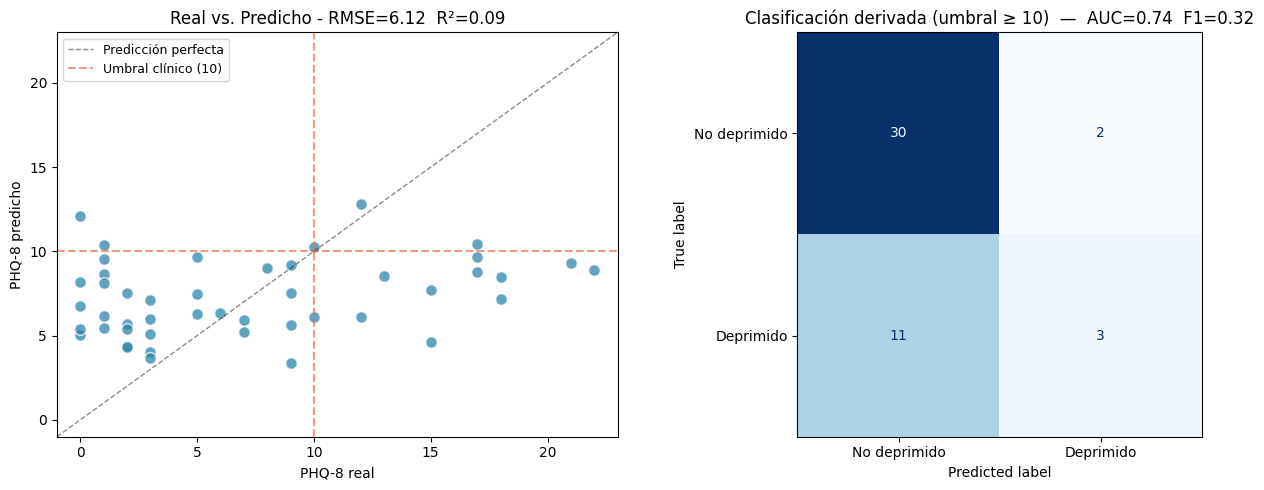

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scatter: PHQ-8 real vs predicho ──────────────────────────────────────────
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
axes[0].scatter(y_test, y_pred, color='#2E86AB', alpha=0.75, edgecolors='white', s=70)
axes[0].plot(lims, lims, 'k--', lw=1, alpha=0.45, label='Predicción perfecta')
axes[0].axvline(PHQ_THRESHOLD, color='#E76F51', lw=1.5, ls='--', alpha=0.7,
                label=f'Umbral clínico ({PHQ_THRESHOLD})')
axes[0].axhline(PHQ_THRESHOLD, color='#E76F51', lw=1.5, ls='--', alpha=0.7)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel('PHQ-8 real')
axes[0].set_ylabel('PHQ-8 predicho')
axes[0].set_title(f'Real vs. Predicho - RMSE={rmse:.2f}  R²={r2:.2f}')
axes[0].legend(fontsize=9)

# ── Matriz de confusión ───────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test_bin, y_pred_bin,
    display_labels=['No deprimido', 'Deprimido'],
    colorbar=False, ax=axes[1], cmap='Blues'
)
axes[1].set_title(f'Clasificación derivada (umbral ≥ {PHQ_THRESHOLD})  -  AUC={auc:.2f}  F1={f1:.2f}')

plt.tight_layout()
plt.show()

## 4. Optimización del umbral de decisión
---
El regresor tiene AUC ≈ 0.69 (ordena razonablemente bien deprimido/no deprimido), pero al aplicar el umbral clínico nominal (PHQ-8 ≥ 10) sobre la predicción continua, casi todos los casos caen por debajo: el modelo, entrenado para minimizar RMSE, predice cerca de la media (~6-7) y rara vez supera 10. El resultado son muchos **falsos negativos** (deprimidos no detectados).

El problema no es el modelo sino el **punto de corte**. Como hay separabilidad (AUC > 0.5), se busca el umbral que maximiza el **F1 de la clase deprimido** en lugar de usar el 10 nominal.

**Sin data leakage:** el umbral se ajusta sobre predicciones *out-of-fold* de train+dev (cada muestra predicha por un modelo que no la vio en su entrenamiento, vía `cross_val_predict`), y se **congela** antes de aplicarlo una única vez al test. Esto convierte el umbral en un hiperparámetro más, seleccionado sin tocar el test.

Es un planteamiento estándar en cribado clínico con clases desbalanceadas: el umbral por defecto está implícitamente optimizado para la clase mayoritaria, y reubicarlo es la palanca más directa para recuperar sensibilidad sobre la minoría.

In [13]:
# Binarización del target en train+dev según umbral clínico
y_traindev_bin = (y_traindev >= PHQ_THRESHOLD).astype(int)

# Predicciones out-of-fold sobre train+dev: cada muestra la predice un pipeline
# (scaler reajustado en su fold + RF) que NO la vio durante el entrenamiento
oof_pred = cross_val_predict(
    clone(search.best_estimator_),
    X_traindev, y_traindev,
    cv=cv_splits,
)

# Barrido de umbrales sobre la predicción continua → maximizar F1 (clase deprimido)
thresholds = np.linspace(oof_pred.min(), oof_pred.max(), 200)
f1_curve = [
    f1_score(y_traindev_bin, (oof_pred >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_thr = thresholds[int(np.argmax(f1_curve))]

print(f"Umbral nominal (PHQ-8)               : {PHQ_THRESHOLD}")
print(f"Umbral óptimo F1 (ajustado en OOF)   : {best_thr:.2f}")
print(f"F1 deprimido en OOF — umbral nominal : "
      f"{f1_score(y_traindev_bin, (oof_pred >= PHQ_THRESHOLD).astype(int), zero_division=0):.3f}")
print(f"F1 deprimido en OOF — umbral óptimo  : {max(f1_curve):.3f}")

Umbral nominal (PHQ-8)               : 10
Umbral óptimo F1 (ajustado en OOF)   : 4.55
F1 deprimido en OOF — umbral nominal : 0.160
F1 deprimido en OOF — umbral óptimo  : 0.506


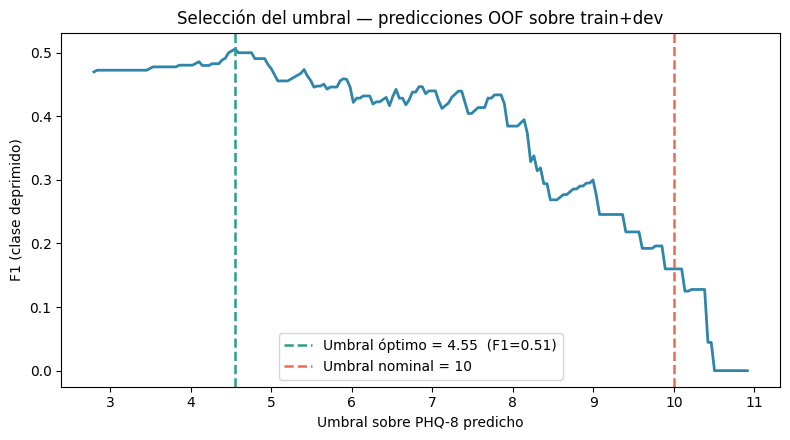

In [14]:
plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, f1_curve, color='#2E86AB', lw=2)
plt.axvline(best_thr, color='#2A9D8F', ls='--', lw=1.8,
            label=f'Umbral óptimo = {best_thr:.2f}  (F1={max(f1_curve):.2f})')
plt.axvline(PHQ_THRESHOLD, color='#E76F51', ls='--', lw=1.8,
            label=f'Umbral nominal = {PHQ_THRESHOLD}')
plt.xlabel('Umbral sobre PHQ-8 predicho')
plt.ylabel('F1 (clase deprimido)')
plt.title('Selección del umbral — predicciones OOF sobre train+dev')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Aplicar ambos umbrales a las predicciones continuas de TEST (y_pred de la sección 3)
def _clf_metrics(y_true_bin, y_score, thr):
    y_hat = (y_score >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_true_bin, y_hat, average='binary', zero_division=0)
    return p, r, f, accuracy_score(y_true_bin, y_hat)

p_nom, r_nom, f_nom, a_nom = _clf_metrics(y_test_bin, y_pred, PHQ_THRESHOLD)
p_opt, r_opt, f_opt, a_opt = _clf_metrics(y_test_bin, y_pred, best_thr)

print("── TEST: umbral nominal (≥10) vs umbral óptimo F1 ──────────")
print(f"{'Métrica':<12}{'Nominal':>10}{'Óptimo':>10}")
print("-" * 32)
print(f"{'Umbral':<12}{PHQ_THRESHOLD:>10.2f}{best_thr:>10.2f}")
print(f"{'Precision':<12}{p_nom:>10.3f}{p_opt:>10.3f}")
print(f"{'Recall':<12}{r_nom:>10.3f}{r_opt:>10.3f}")
print(f"{'F1':<12}{f_nom:>10.3f}{f_opt:>10.3f}")
print(f"{'Accuracy':<12}{a_nom:>10.3f}{a_opt:>10.3f}")
print(f"\nAUC (no depende del umbral): {auc:.3f}")

── TEST: umbral nominal (≥10) vs umbral óptimo F1 ──────────
Métrica        Nominal    Óptimo
--------------------------------
Umbral           10.00      4.55
Precision        0.600     0.341
Recall           0.214     1.000
F1               0.316     0.509
Accuracy         0.717     0.413

AUC (no depende del umbral): 0.737


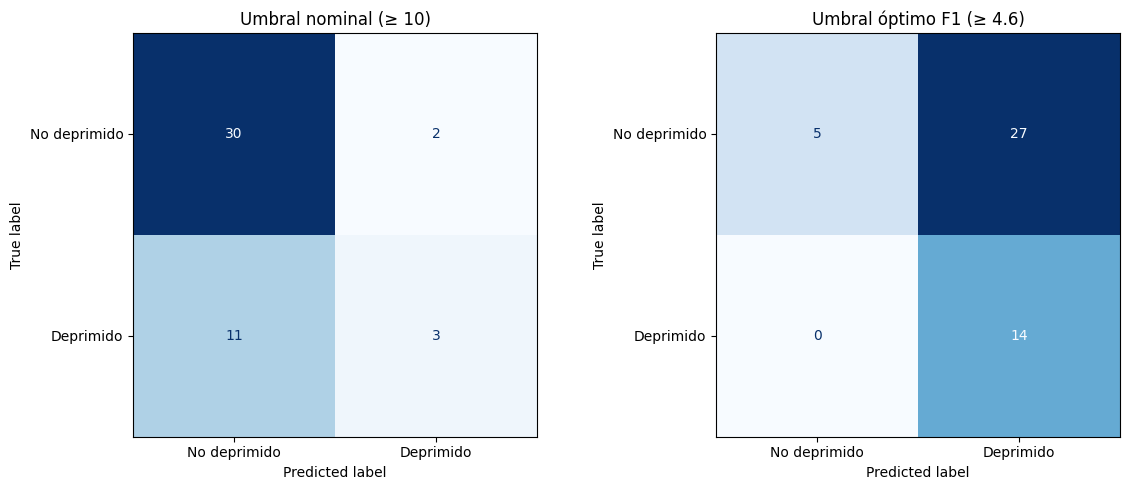

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, thr, title in [
    (axes[0], PHQ_THRESHOLD, f'Umbral nominal (≥ {PHQ_THRESHOLD})'),
    (axes[1], best_thr,      f'Umbral óptimo F1 (≥ {best_thr:.1f})'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test_bin, (y_pred >= thr).astype(int),
        display_labels=['No deprimido', 'Deprimido'],
        colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 5. Importancia de variables - SHAP
---
`TreeExplainer` calcula los valores de Shapley exactos sobre el Random Forest. Como el modelo es un **pipeline** (`gender → dropgender → scaler → select → rf`), se separan los transformadores ajustados y el RF: el test se transforma con ellos y SHAP explica el RF sobre las **K_FEATURES seleccionadas** (mismas para ambos modelos).

Para un regresor, `shap_values` es una única matriz (n_muestras × n_features): cada valor representa cuánto contribuye esa feature a desplazar la predicción de PHQ-8 respecto a la media del train. Valores positivos empujan hacia PHQ-8 alto (más síntomas); negativos, hacia PHQ-8 bajo.

> **Lectura de los valores de las features:** aparecen en el espacio transformado — las acústicas **normalizadas por género** (z-score intra-sexo) y todas **estandarizadas**. Un valor alto (rojo) significa "alto en términos relativos". El escalado es monótono por variable, así que la **dirección** del efecto se mantiene; solo cambian las unidades del color.

- **Beeswarm plot**: distribución de SHAP por feature, coloreado por valor de la feature. Importancia y dirección del efecto a la vez.
- **Bar plot**: importancia media |SHAP| — ranking agregado.

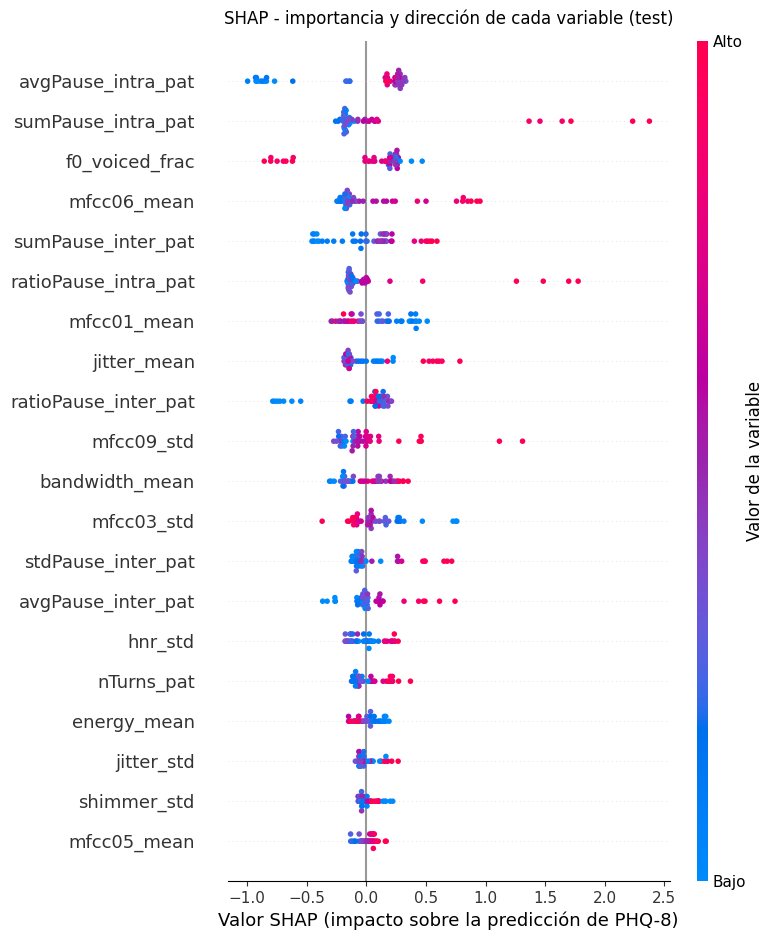

In [17]:
# rf_final es un Pipeline (gender → dropgender → scaler → select → rf): separamos
# los transformadores ajustados y el RF para explicar el árbol sobre el mismo espacio
gender_fitted = rf_final.named_steps['gender']
drop_fitted   = rf_final.named_steps['dropgender']
scaler_fitted = rf_final.named_steps['scaler']
select_fitted = rf_final.named_steps['select']
rf_fitted     = rf_final.named_steps['rf']

# Nombres de las features que llegan al RF (tras drop de gender + selección)
cols_after_drop = [c for c in COLS_FEATURES if c not in drop_fitted.cols]
feat_names = [c for c, keep in zip(cols_after_drop, select_fitted.get_support()) if keep]

# El test se transforma con las estadísticas aprendidas en train+dev
X_test_scaled = pd.DataFrame(
    select_fitted.transform(
        scaler_fitted.transform(drop_fitted.transform(gender_fitted.transform(X_test)))
    ),
    columns=feat_names,
)

explainer   = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_test_scaled)
# Para regresor: shap_values es array 2D (n_muestras × n_features), sin indexar por clase

plt.figure()
shap.summary_plot(shap_values, X_test_scaled, plot_type='dot',
                  max_display=20, show=False)
# rotulos en castellano (la libreria SHAP los genera en ingles)
_fig = plt.gcf()
plt.gca().set_xlabel('Valor SHAP (impacto sobre la predicción de PHQ-8)')
for _a in _fig.axes[1:]:
    if _a.get_ylabel() == 'Feature value':
        _a.set_ylabel('Valor de la variable')
        if len(_a.get_yticklabels()) == 2:
            _a.set_yticklabels(['Bajo', 'Alto'])
plt.title('SHAP - importancia y dirección de cada variable (test)', pad=12)
plt.tight_layout()
plt.show()

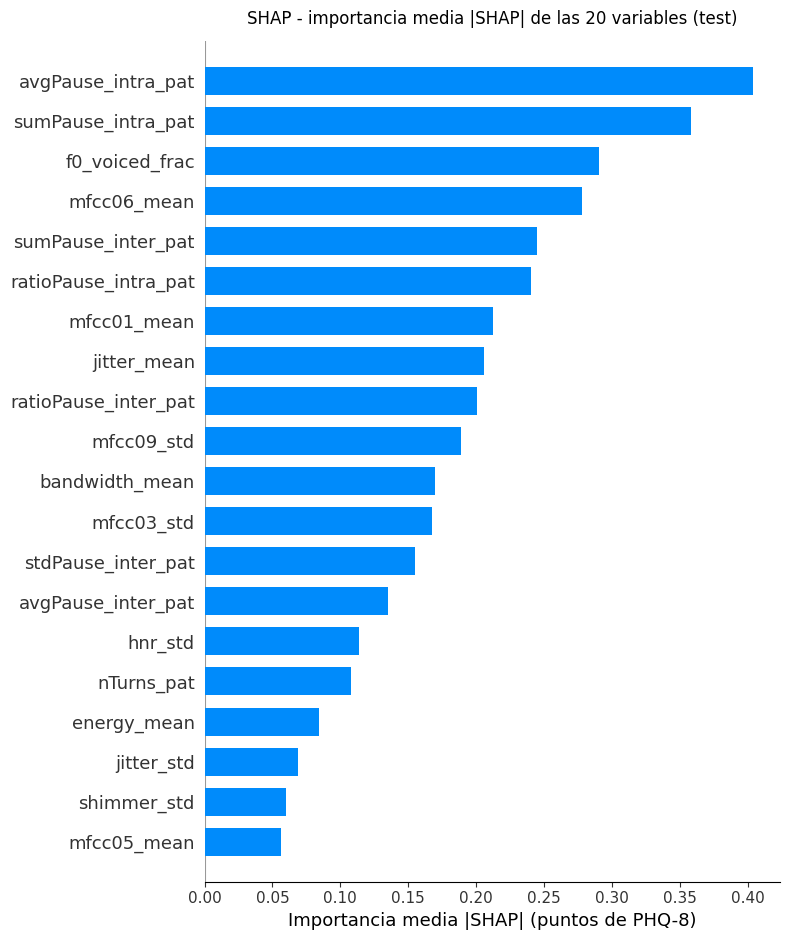

In [18]:
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar',
                  max_display=20, show=False)
# rotulo en castellano (la libreria SHAP lo genera en ingles)
plt.gca().set_xlabel('Importancia media |SHAP| (puntos de PHQ-8)')
plt.title('SHAP - importancia media |SHAP| de las 20 variables (test)', pad=12)
plt.tight_layout()
plt.show()